# ⚙️ A Mecânica da Iteração
## *Uma Obra de Da Vinci em Python*

> *"A simplicidade é a sofisticação máxima."* — Leonardo da Vinci

```
╔══════════════════════════════════════════════════════════════════════════╗
║                                                                          ║
║   PYTHON RUNTIME                                                         ║
║   ┌─────────────────────────────────────────────────────────────┐        ║
║   │                                                             │        ║
║   │   O GERADOR               A ESTEIRA (Iterator State)        │        ║
║   │   (Código Fonte)          ┌───┬───┬───┬───┬───┐            │        ║
║   │   ┌──────────┐            │ 1 │ 2 │ 3 │ 4 │ 5 │ ──►        │        ║
║   │   │def gen():│            └───┴───┴───┴───┴───┘            │        ║
║   │   │  yield 1 │                 ▲                            │        ║
║   │   │  yield 2 │           next()║ play/pausa                 │        ║
║   │   │  yield 3 │                 ║                            │        ║
║   │   └──────────┘           ESTADO SALVO (Memória)             │        ║
║   │                          "onde a esteira parou"             │        ║
║   └─────────────────────────────────────────────────────────────┘        ║
║                                                                          ║
║   MANTRA: "Não Fatiar o Futuro — Consuma o Fluxo"                       ║
╚══════════════════════════════════════════════════════════════════════════╝
```

---

## O Mapa da Obra

| Conceito | Metáfora Da Vinci | Python |
|---|---|---|
| **Iterable** | O livro de esboços (tem as páginas) | `list`, `str`, `range` |
| **Iterator** | O dedo que percorre as páginas | objeto com `__next__()` |
| **iter()** | Abrir o livro na página 1 | `it = iter(lista)` |
| **next()** | Virar uma página | `val = next(it)` |
| **Generator** | O artista que desenha só quando pedido | função com `yield` |
| **yield** | "Até logo" — pausa e entrega | `yield valor` |
| **return** | "Adeus" — entrega e fecha o ateliê | `return valor` |


---
# 📜 Capítulo 1 — Iterable vs Iterator
## *"O livro não lê a si mesmo — você precisa de um dedo."*

```
ITERABLE                         ITERATOR
(tem os dados)                   (sabe onde está)

   lista = [1, 2, 3]
       │
       │  iter(lista)
       ▼
   it = lista.__iter__()   ◄──── Estado: posição atual = 0
       │
       │  next(it)
       ▼
   1   ◄──────────────────────── Estado: posição atual = 1
       │
       │  next(it)
       ▼
   2   ◄──────────────────────── Estado: posição atual = 2
       │
       │  next(it)
       ▼
   3   ◄──────────────────────── Estado: posição atual = 3
       │
       │  next(it)
       ▼
   StopIteration  ◄─────────────  Fim da esteira. Joga a exceção.
```

> **Regra de ouro:** Todo `Iterator` é um `Iterable`, mas nem todo `Iterable` é um `Iterator`.
> Uma `list` é um `Iterable`. `iter(list)` retorna um `Iterator`.


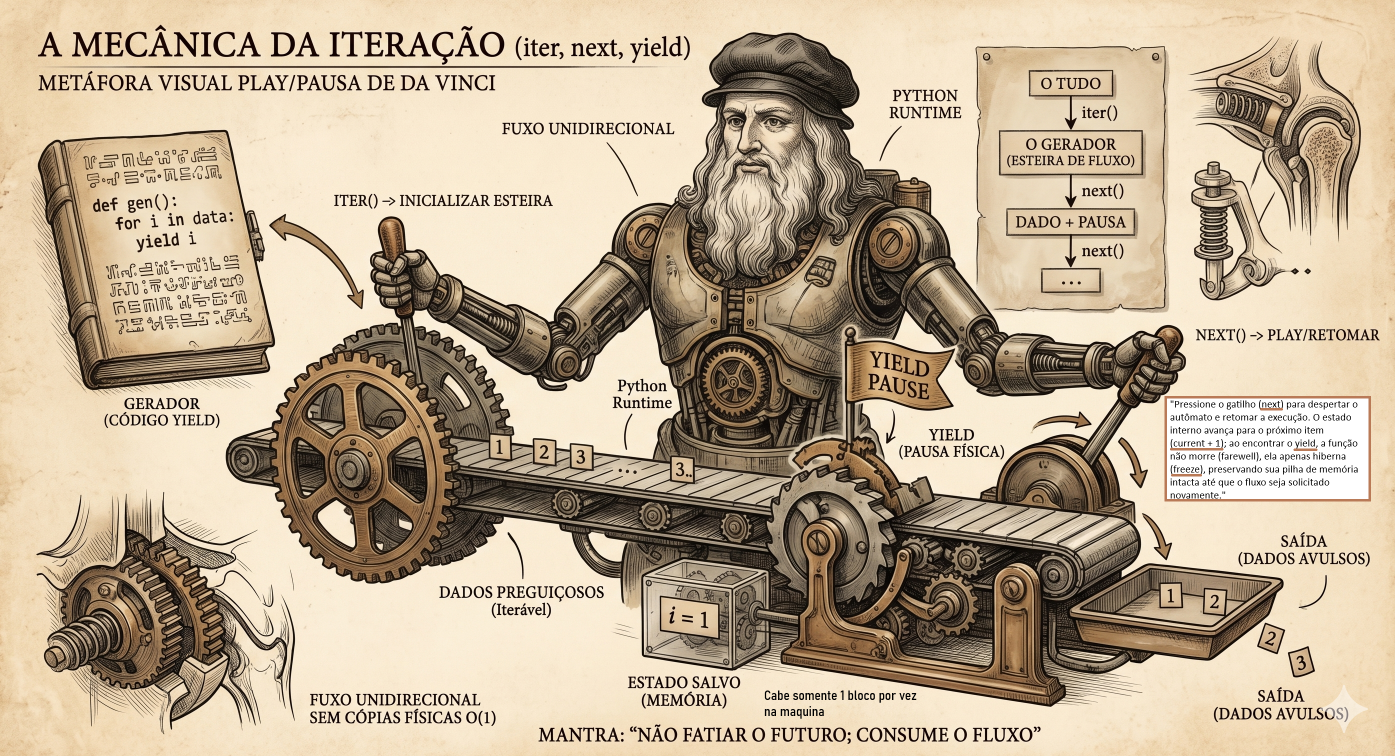

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Experimento 1: Dissecando o for loop como Da Vinci dissecaria um corpo
# O for loop é apenas açúcar sintático para iter() + next()
# ─────────────────────────────────────────────────────────────────

nums = [1, 2, 3]

print("=== O que o Python faz por baixo do pano ===")
print()

# O que VOCÊ escreve:
print(">>> for n in nums: print(n)")
for n in nums:
    print(f"   {n}")

print()

# O que o Python REALMENTE faz:
print(">>> it = iter(nums)  ←── abre o livro na página 1")
it = iter(nums)

print(f">>> type(it)         → {type(it)}")  # list_iterator
print(f">>> it is nums       → {it is nums}")  # False — são objetos DIFERENTES
print()

print(">>> next(it)  →", next(it), " ←── lê e vira a página")
print(">>> next(it)  →", next(it))
print(">>> next(it)  →", next(it))
print()

try:
    print(">>> next(it)  →", next(it))
except StopIteration:
    print(">>> next(it)  → StopIteration! ←── fim da esteira")

print()
print("A lista original ainda existe intacta:", nums)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Experimento 2: Construindo seu próprio Iterator à moda Da Vinci
# Implementando __iter__ e __next__ manualmente
# ─────────────────────────────────────────────────────────────────

class Counter:
    """
    Um iterator artesanal — feito à mão como nos cadernos de Da Vinci.
    Conta de 'start' até 'end', um número por vez.
    """
    def __init__(self, start: int, end: int):
        self.current = start
        self.end = end

    def __iter__(self):
        # Sou meu próprio iterator — retorno a mim mesmo
        return self

    def __next__(self):
        if self.current > self.end:
            raise StopIteration  # Fim da esteira
        value = self.current
        self.current += 1        # Avança o estado interno
        return value


print("=== Nosso Iterator artesanal ===")
counter = Counter(1, 5)

# Funciona com for! Python chama __iter__ e __next__ automaticamente
for n in counter:
    print(f"   {n}")

print()
print("Prova: iter(Counter) retorna ele mesmo?", iter(Counter(1, 3)) is not None)


---
# 🎨 Capítulo 2 — `yield` e Generators
## *"`return` é um adeus. `yield` é um 'até logo'."*

```
FUNÇÃO NORMAL (return)              GENERATOR (yield)
──────────────────────              ─────────────────

def dobrar(n):                      def dobrar_gen(n):
    return n * 2                        yield n * 2
        │                                   │
        ▼                                   ▼
  Calcula TUDO,               Pausa aqui, salva o estado,
  entrega TUDO,               entrega UM valor,
  fecha o ateliê.             espera o próximo next().


  Memória: O(N)                   Memória: O(1)
  (guarda todos os resultados)    (guarda só o estado atual)
```

### Por que `yield` é o truque de mestre?

| Situação | `return` (Lista) | `yield` (Generator) |
|---|---|---|
| 1 milhão de números | Aloca 1M na RAM | Usa ~200 bytes |
| Precisa de todos de uma vez | ✅ | ❌ use list() |
| Processa um por vez | Desperdício | ✅ perfeito |
| Pode ser infinito | ❌ trava | ✅ funciona |


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Experimento 3: yield — o Play/Pausa da esteira de Da Vinci
# Visualizando EXATAMENTE onde a execução para e recomeça
# ─────────────────────────────────────────────────────────────────

def my_generator():
    print("   [ATELIÊ] Da Vinci pega o pincel...")
    yield 1                        # ← PAUSA AQUI. Entrega 1.

    print("   [ATELIÊ] next() chamado — Da Vinci continua...")
    yield 2                        # ← PAUSA AQUI. Entrega 2.

    print("   [ATELIÊ] Último traço...")
    yield 3                        # ← PAUSA AQUI. Entrega 3.

    print("   [ATELIÊ] Ateliê fechado. StopIteration.")
    # Função termina → StopIteration automático


print("=== Criando o generator (NADA executa ainda!) ===")
gen = my_generator()
print(f"   type(gen) = {type(gen)}")  # <generator object>
print()

print("=== next(gen) — 1ª chamada ===")
val = next(gen)
print(f"   recebemos: {val}")
print()

print("=== next(gen) — 2ª chamada ===")
val = next(gen)
print(f"   recebemos: {val}")
print()

print("=== next(gen) — 3ª chamada ===")
val = next(gen)
print(f"   recebemos: {val}")
print()

print("=== next(gen) — 4ª chamada ===")
try:
    next(gen)
except StopIteration:
    print("   StopIteration capturada!")


---
# 🔬 Capítulo 3 — O Truque do `iter()` na FAANG
## *"A diferença entre o NeetCode e o código Sênior"*

```
NEETCODE (Universal, mas lento)        PYTHONISTA SÊNIOR (O seu truque)
────────────────────────────────       ─────────────────────────────────

val = data.pop(0)      O(N) ❌         val = next(it)         O(1) ✅
self.i += 1            Manual ❌       it avança sozinho      Automático ✅
dfs(data[1:])          Copia lista ❌  dfs(it)                Mesma esteira ✅
```

### Por que `next(it)` é tão poderoso na DFS?

Quando você serializa uma árvore e usa `iter()` para deserializar,
a esteira compartilhada entre TODAS as chamadas recursivas é o que
elimina a necessidade de índices globais ou `deque.popleft()`.

```
Serializado: "1,2,4,#,#,5,#,#,3,6,#,#,7,#,#"
                │
                it = iter(data.split(","))
                │
                ▼
           dfs(it) → val=next(it)="1" → cria nó 1
                          │
                    ┌─────┴─────┐
               dfs(it)       dfs(it)
               val="2"        (espera)
                 │
           ┌─────┴─────┐
          dfs(it)    dfs(it)
          val="4"    (espera)
            │
       ┌────┴────┐
      dfs(it)  dfs(it)
      val="#"  val="#"   ← mesma esteira! O it já está em "5"
```


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Experimento 4: iter() como esteira compartilhada na DFS
# Este é o "Aha! Moment" — o mesmo it é consumido pela recursão inteira
# ─────────────────────────────────────────────────────────────────

def demonstrate_shared_iterator():
    """
    Simula como a DFS da árvore "consome" a esteira.
    Cada chamada recursiva avança o MESMO iterator.
    """
    data = ["1", "2", "4", "#", "#", "5", "#", "#", "3", "#", "#"]
    it = iter(data)
    depth = [0]  # Para visualização da profundidade

    def dfs(label="root"):
        val = next(it)  # ← O TRUQUE: avança a esteira global
        indent = "  " * depth[0]
        print(f"{indent}dfs({label}) → consumiu '{val}'")

        if val == "#":
            return None

        # Subárvore esquerda e direita — avançam a MESMA esteira
        depth[0] += 1
        left = dfs("left")
        right = dfs("right")
        depth[0] -= 1
        return (val, left, right)

    print("=== Esteira compartilhada na DFS ===")
    print(f"    Dados: {data}")
    print(f"    it = iter(data)  ← uma única esteira para toda a recursão")
    print()
    tree = dfs()
    print()
    print(f"Árvore reconstruída: {tree}")


demonstrate_shared_iterator()


---
# 🌀 Capítulo 4 — Generators: O Artista Preguiçoso
## *"Lazy Evaluation — só desenha quando pedido"*

```
ANSIOSO (list comprehension)          PREGUIÇOSO (generator expression)

quadrados = [x**2 for x in range(10)]   quadrados = (x**2 for x in range(10))
    │                                         │
    ▼                                         ▼
[0,1,4,9,16,25,36,49,64,81]            <generator object>
 ↑                                      ↑
 Todos calculados AGORA                 Nenhum calculado ainda!
 Memória: O(N)                         Memória: O(1)

sys.getsizeof([...]) = ~184 bytes      sys.getsizeof(gen) = ~104 bytes
(para N=10, mas escala com N)          (SEMPRE o mesmo tamanho)
```

### Generators são Iterators que escrevem a si mesmos

> Você não precisa implementar `__iter__` e `__next__` manualmente.
> Uma função com `yield` já é um generator — e todo generator é um iterator.


In [ ]:
import sys

# ─────────────────────────────────────────────────────────────────
# Experimento 5: Generator vs List — batalha de memória
# ─────────────────────────────────────────────────────────────────

N = 1_000_000

# Ansioso: aloca tudo na memória agora
squares_list = [x ** 2 for x in range(N)]

# Preguiçoso: não aloca nada ainda
squares_gen = (x ** 2 for x in range(N))

print("=== Comparação de Memória ===")
print(f"   list comprehension [{N:,}]:  {sys.getsizeof(squares_list):>12,} bytes  ← O(N)")
print(f"   generator expression:        {sys.getsizeof(squares_gen):>12,} bytes  ← O(1) sempre")
print()

# Ambos produzem o mesmo resultado quando consumidos
print("=== Mesmo resultado, custo diferente ===")
sum_list = sum(squares_list)
sum_gen  = sum(x ** 2 for x in range(N))  # recria pois squares_gen já foi consumido
print(f"   sum(list) = {sum_list:,}")
print(f"   sum(gen)  = {sum_gen:,}")
print(f"   Iguais? {sum_list == sum_gen}")
print()

# ─────────────────────────────────────────────────────────────────
# Generator INFINITO — impossível com lista
# ─────────────────────────────────────────────────────────────────
def fibonacci():
    """Generator infinito de Fibonacci — só existe com yield."""
    a, b = 0, 1
    while True:       # ← infinito! Mas a memória é O(1)
        yield a
        a, b = b, a + b

print("=== Fibonacci infinito (impossível com lista) ===")
fib = fibonacci()
first_10 = [next(fib) for _ in range(10)]
print(f"   Primeiros 10: {first_10}")


---
# 🏛️ Capítulo 5 — `yield from` e Pipelines
## *"Conectando os ateliês — a cadeia de produção de Da Vinci"*

```
PIPELINE DE GENERATORS

   fonte()          filtrar()        transformar()
   ┌──────┐         ┌──────────┐     ┌──────────────┐
   │yield 1│──next──►│if n%2==0 │─────►│yield n * 10  │──► 20, 40, 60...
   │yield 2│         │  yield n │     └──────────────┘
   │yield 3│         └──────────┘
   │  ...  │
   └──────┘

Nenhum dado existe em memória até ser consumido.
É como uma linha de montagem: cada peça só avança quando pedida.
```


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Experimento 6: Pipeline de generators + yield from
# ─────────────────────────────────────────────────────────────────

def source(n: int):
    """Generator 1: produz números de 1 a n."""
    for i in range(1, n + 1):
        yield i

def only_evens(it):
    """Generator 2: filtra, passando só os pares."""
    for n in it:
        if n % 2 == 0:
            yield n

def multiply(it, factor: int):
    """Generator 3: transforma multiplicando pelo fator."""
    for n in it:
        yield n * factor

# Pipeline: nenhum dado é calculado ainda
pipeline = multiply(only_evens(source(10)), factor=100)

print("=== Pipeline de Generators ===")
print("   source(10) → only_evens → multiply(×100)")
print()
for result in pipeline:
    print(f"   {result}")

print()

# ─── yield from: delegar para outro generator ───────────────────
def tree_dfs(nodes):
    """
    Percorre uma estrutura aninhada com yield from.
    yield from delega a iteração para o sub-generator.
    """
    for node in nodes:
        if isinstance(node, list):
            yield from tree_dfs(node)   # ← delega recursivamente
        else:
            yield node

structure = [1, [2, [4, 5]], [3, [6, 7]]]

print("=== yield from — DFS em estrutura aninhada ===")
print(f"   Estrutura: {structure}")
print(f"   DFS:       {list(tree_dfs(structure))}")


---
# 📐 Capítulo 6 — O Compêndio Final
## *"Tudo que Da Vinci precisaria saber sobre iteração"*

```
╔══════════════════════════════════════════════════════════════════╗
║              HIERARQUIA DA ITERAÇÃO EM PYTHON                   ║
║                                                                  ║
║    Iterable                                                      ║
║    ├── tem __iter__()                                            ║
║    ├── exemplos: list, str, dict, range, set, tuple              ║
║    └── NÃO lembra onde parou                                     ║
║                                                                  ║
║    Iterator  (é também um Iterable)                              ║
║    ├── tem __iter__() E __next__()                               ║
║    ├── lembra onde parou (estado interno)                        ║
║    ├── só anda pra frente — sem reset                            ║
║    └── exemplos: iter(lista), file objects, zip, map, filter     ║
║                                                                  ║
║    Generator  (é um Iterator especializado)                      ║
║    ├── criado por função com yield                               ║
║    ├── ou por generator expression (x for x in ...)             ║
║    ├── memória O(1) — calcula sob demanda                        ║
║    └── pode ser infinito                                         ║
╚══════════════════════════════════════════════════════════════════╝
```

## Tradução NeetCode → Pythonista Sênior

| Operação | Código Ingênuo | Código Pythônico | Complexidade |
|---|---|---|---|
| Consumir primeiro | `data.pop(0)` | `next(it)` | O(N) → **O(1)** |
| Índice manual | `self.i += 1` | `it` avança sozinho | Manual → **Auto** |
| Passar sublista | `dfs(data[1:])` | `dfs(it)` | O(N) cópia → **O(1)** |
| Sequência lazy | `[f(x) for x in ...]` | `(f(x) for x in ...)` | O(N) mem → **O(1)** |
| Sub-generator | loop manual | `yield from sub()` | Verboso → **Elegante** |

---

> *"O verdadeiro gênio está em fazer o complexo parecer simples."*
> — Adaptado de Da Vinci
>
> Em Python: `val = next(it)` é a sofisticação máxima.
